# Phase 2: Exploratory Data Analysis

Runs only on `data/train.csv` (never `data/test.csv`) to avoid peeking at the held-out set, consistent with the leakage discussion in the README.

In [1]:
import re
from urllib.parse import urlparse

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", None)

# Categorical palette (validated colorblind-safe pair, fixed order - see dataviz skill).
COLOR_LEGIT = "#2a78d6"    # blue -> label 1 (legitimate)
COLOR_PHISH = "#eb6834"    # orange -> label 0 (phishing)
LABELS = {1: "Legitimate", 0: "Phishing"}

FIG_DIR = "../reports/figures"

train = pd.read_csv("../data/train.csv")
print(train.shape)
train.head()


(188296, 2)


,URL,label
0,https://xxx.7a7.myftpupload.com/.pki/nssdb/frt...,0
1,https://www.jesuisanimateur.fr,1
2,http://www.e100.net,0
3,https://www.apocalypselaterfilm.com,1
4,https://b4e921f0.sso-mailsrvr-4344e5teed.pages...,0


## 1. Class balance

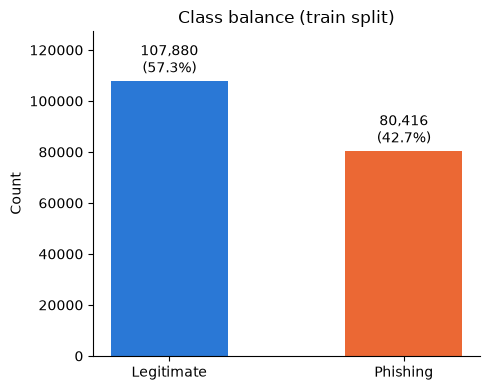

label
1    0.572928
0    0.427072
Name: proportion, dtype: float64


In [2]:
counts = train["label"].value_counts().reindex([1, 0])

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(
    [LABELS[i] for i in counts.index],
    counts.values,
    color=[COLOR_LEGIT, COLOR_PHISH],
    width=0.5,
)
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 1500, f"{v:,}\n({v/len(train):.1%})",
            ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Count")
ax.set_title("Class balance (train split)")
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, counts.max() * 1.18)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/01_class_balance.png", dpi=150)
plt.show()

print(train["label"].value_counts(normalize=True))


## 2. Derive raw URL characteristics (ad-hoc, EDA only)

These are quick, exploratory versions used only to look at the data. The real, documented, rationale-backed feature extractor is built independently in Phase 3 — this cell exists to decide *which* characteristics are worth turning into features, not to define the final feature set.

In [3]:
IP_PATTERN = re.compile(
    r"^(\d{1,3}\.){3}\d{1,3}$|^0x[0-9a-fA-F]+$"  # dotted-decimal or hex-encoded IP
)
SHORTENERS = {
    "bit.ly", "tinyurl.com", "goo.gl", "t.co", "ow.ly", "is.gd", "buff.ly",
    "adf.ly", "bit.do", "shorte.st", "cutt.ly", "rebrand.ly", "tiny.cc",
    "rb.gy", "shorturl.at", "clck.ru", "s.id", "lnkd.in",
}


def parsed_host(url: str) -> str:
    p = urlparse(url if "://" in url else "http://" + url)
    return (p.hostname or "").lower()


def eda_features(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=df.index)
    out["url_length"] = df["URL"].str.len()
    hosts = df["URL"].apply(parsed_host)
    out["host"] = hosts
    out["is_https"] = df["URL"].str.lower().str.startswith("https")
    out["is_ip_domain"] = hosts.apply(lambda h: bool(IP_PATTERN.match(h)))
    out["has_at_symbol"] = df["URL"].str.contains("@", regex=False)
    out["subdomain_count"] = hosts.apply(lambda h: max(h.count(".") - 1, 0) if h else 0)
    out["is_shortener"] = hosts.apply(lambda h: h in SHORTENERS)
    out["label"] = df["label"]
    return out


eda = eda_features(train)
eda.describe(include="all")


,url_length,host,is_https,is_ip_domain,has_at_symbol,subdomain_count,is_shortener,label
count,188296.000000,188296,188296,188296,188296,188296.000000,188296,188296.000000
unique,NaN,176935,2,2,2,NaN,2,NaN
top,NaN,ipfs.io,True,False,False,NaN,False,NaN
freq,NaN,968,146948,187799,187098,NaN,187709,NaN
mean,35.409711,NaN,NaN,NaN,NaN,1.164544,NaN,0.572928
std,42.757101,NaN,NaN,NaN,NaN,0.600879,NaN,0.494654
min,14.000000,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000
25%,24.000000,NaN,NaN,NaN,NaN,1.000000,NaN,0.000000
50%,28.000000,NaN,NaN,NaN,NaN,1.000000,NaN,1.000000
75%,35.000000,NaN,NaN,NaN,NaN,1.000000,NaN,1.000000


## 3. URL length by class

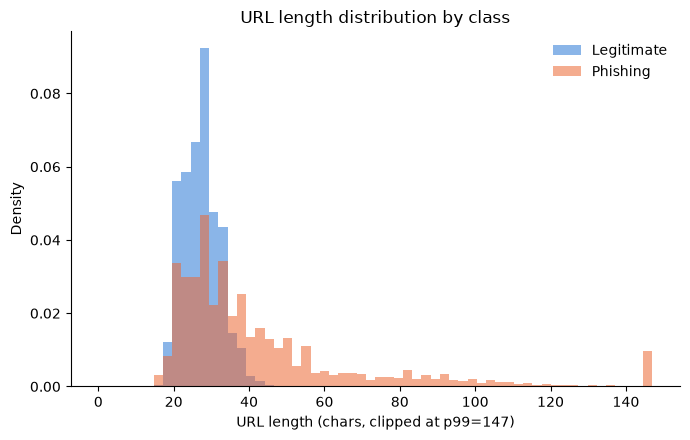

            mean   50%        std
label                            
0      46.397334  34.0  63.552586
1      27.219308  27.0   4.813203


In [4]:
# Clip the x-axis at the 99th percentile so a handful of extreme outliers
# don't compress the histogram; note the clip in the axis label.
clip = int(eda["url_length"].quantile(0.99))
bins = 60

fig, ax = plt.subplots(figsize=(7, 4.5))
for lbl, color in [(1, COLOR_LEGIT), (0, COLOR_PHISH)]:
    vals = eda.loc[eda["label"] == lbl, "url_length"].clip(upper=clip)
    ax.hist(vals, bins=bins, range=(0, clip), color=color, alpha=0.55,
            label=LABELS[lbl], density=True)
ax.set_xlabel(f"URL length (chars, clipped at p99={clip})")
ax.set_ylabel("Density")
ax.set_title("URL length distribution by class")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/02_url_length_by_class.png", dpi=150)
plt.show()

print(eda.groupby("label")["url_length"].describe()[["mean", "50%", "std"]])


## 4. Binary structural flags by class: HTTPS, IP-as-domain, `@` symbol, URL shortener

       is_https  is_ip_domain  has_at_symbol  is_shortener
label                                                     
0      0.485824       0.00618       0.014898        0.0073
1      1.000000       0.00000       0.000000        0.0000


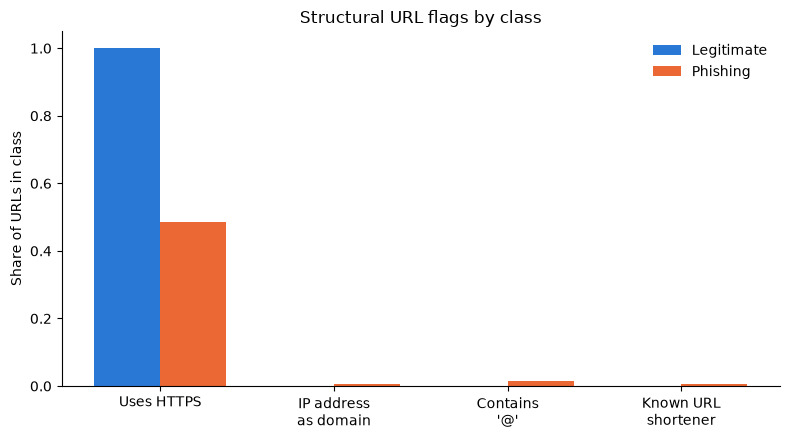

In [5]:
flags = ["is_https", "is_ip_domain", "has_at_symbol", "is_shortener"]
flag_labels = ["Uses HTTPS", "IP address\nas domain", "Contains\n'@'", "Known URL\nshortener"]

rate_by_class = eda.groupby("label")[flags].mean()  # fraction True, per class
print(rate_by_class)

x = range(len(flags))
width = 0.38
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar([i - width/2 for i in x], rate_by_class.loc[1, flags], width,
       label=LABELS[1], color=COLOR_LEGIT)
ax.bar([i + width/2 for i in x], rate_by_class.loc[0, flags], width,
       label=LABELS[0], color=COLOR_PHISH)
ax.set_xticks(list(x))
ax.set_xticklabels(flag_labels)
ax.set_ylabel("Share of URLs in class")
ax.set_title("Structural URL flags by class")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/03_structural_flags_by_class.png", dpi=150)
plt.show()


## 5. Subdomain count by class

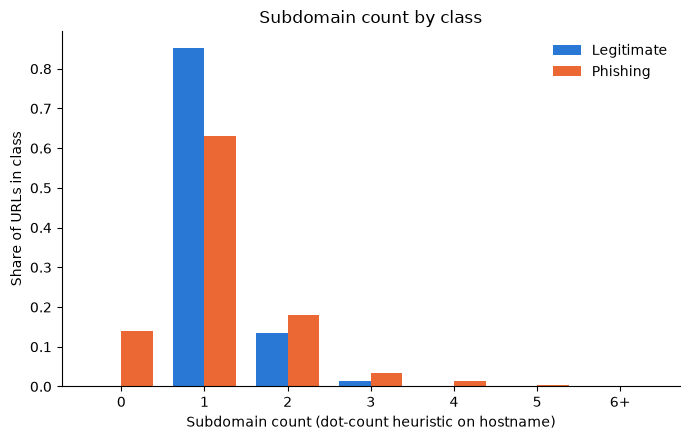

           mean  50%   max
label                     
0      1.168337  1.0  10.0
1      1.161717  1.0   4.0


In [6]:
max_sub = 6  # bucket 6+ together; long tail beyond this is rare and hard to read
eda["subdomain_count_capped"] = eda["subdomain_count"].clip(upper=max_sub)
counts_tbl = (
    eda.groupby(["subdomain_count_capped", "label"]).size().unstack("label").fillna(0)
)
counts_tbl = counts_tbl.div(counts_tbl.sum(axis=0), axis=1)  # normalize within class

fig, ax = plt.subplots(figsize=(7, 4.5))
x = counts_tbl.index.to_numpy()
width = 0.38
ax.bar(x - width/2, counts_tbl[1], width, label=LABELS[1], color=COLOR_LEGIT)
ax.bar(x + width/2, counts_tbl[0], width, label=LABELS[0], color=COLOR_PHISH)
ax.set_xticks(list(x))
ax.set_xticklabels([str(i) for i in x[:-1]] + [f"{max_sub}+"])
ax.set_xlabel("Subdomain count (dot-count heuristic on hostname)")
ax.set_ylabel("Share of URLs in class")
ax.set_title("Subdomain count by class")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/04_subdomain_count_by_class.png", dpi=150)
plt.show()

print(eda.groupby("label")["subdomain_count"].describe()[["mean", "50%", "max"]])


## Findings summary

1. **HTTPS usage is the cleanest separator in this dataset**: 100% of legitimate URLs use HTTPS vs. only 48.6% of phishing URLs. This is a strong, visually obvious separation — but the fact that it's *exactly* 100% on the legitimate side is itself a flag that PhiUSIIL's legitimate-URL collection likely required or strongly favored HTTPS-serving live sites, so this feature may be a "too easy" artifact of how this specific dataset was built rather than a universal truth about legitimate URLs (a point noted here and revisited in Phase 6/Limitations).
2. **URL length also separates the classes, but asymmetrically**: phishing URLs average 46.4 characters (median 34, std 63.6 — a long right tail, presumably from embedded redirect tokens/paths), while legitimate URLs are tightly clustered around 27 characters (std only 4.8). The near-zero variance on the legitimate side again looks like a dataset-construction artifact (legitimate URLs here are mostly bare `https://www.domain.tld` with little path depth) rather than a fact about legitimate URLs in general — worth keeping in mind when interpreting how well this feature will generalize.
3. **IP-address-as-domain, the `@` symbol, and known URL shorteners — three "classic" phishing signals from the literature — show essentially no separation in this dataset**: all three are rare on both sides (IP-domain 0.6% phishing vs. 0% legit; `@` 1.5% vs. 0%; shorteners 0.7% vs. 0%). They're still worth engineering as features in Phase 3 (their absence here doesn't mean they're never useful — sparse, high-precision signals can still help a model even at low prevalence, and they remain textbook phishing indicators worth having on file) but they are correctly flagged now as *weak* candidates in this particular dataset rather than being oversold.
4. **Subdomain count barely differs by class** (mean 1.17 phishing vs. 1.16 legitimate, same median of 1) — the simple dot-count heuristic used here doesn't distinguish the classes on its own, though it may still contribute in combination with other features in a multivariate model.
5. **Net takeaway for Phase 3**: URL length and HTTPS usage are the strongest univariate candidates from this EDA pass, but both carry a dataset-artifact caveat, so Phase 3 also leans on features EDA can't easily visualize here — suspicious-keyword presence and URL/domain entropy — to avoid over-relying on two signals that might be partly measuring "how PhiUSIIL was built" rather than "what makes a URL phishing."